<a href="https://colab.research.google.com/github/jesicaroman17-cpu/Intro_ciencia-datos-JR/blob/main/Trabajo_Final_Ciencia_de_Datos_PARTE2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer, MissingIndicator
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)

df = pd.read_csv('/content/info_creditos_trabajo_final.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,grupo_edad,grupo_ingreso,nivel_endeudamiento,endeudamiento_critico,riesgo_alto,default_historico,vivienda_rentada,historial_largo
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,18-25,Bajo,Bajo,0,0,0,0,0
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,18-25,Bajo,Critico,1,0,0,0,0
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,18-25,Alto,Critico,1,0,0,1,0
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,18-25,Medio,Critico,1,0,1,1,0
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,18-25,Bajo,Alto,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32409 entries, 0 to 32408
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32409 non-null  int64  
 1   person_income               32409 non-null  int64  
 2   person_home_ownership       32409 non-null  object 
 3   person_emp_length           32409 non-null  float64
 4   loan_intent                 32409 non-null  object 
 5   loan_grade                  32409 non-null  object 
 6   loan_amnt                   32409 non-null  int64  
 7   loan_int_rate               32409 non-null  float64
 8   loan_status                 32409 non-null  int64  
 9   loan_percent_income         32409 non-null  float64
 10  cb_person_default_on_file   32409 non-null  object 
 11  cb_person_cred_hist_length  32409 non-null  int64  
 12  grupo_edad                  32409 non-null  object 
 13  grupo_ingreso               324

In [5]:
X = df.drop(columns='loan_status')
y = df['loan_status']

num_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'endeudamiento_critico', 'riesgo_alto', 'default_historico', 'vivienda_rentada', 'historial_largo' ]
cat_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']
ord_cols = ['loan_grade', 'grupo_edad', 'grupo_ingreso', 'nivel_endeudamiento']

ordinal_orders = {
    'loan_grade': ['A','B','C','D','E','F','G'],
    'grupo_edad': ['18-25', '26-35', '36-50', '50+'],
    'grupo_ingreso': ['Bajo', 'Medio', 'Alto', 'Muy Alto'],
    'nivel_endeudamiento': ['Bajo', 'Medio', 'Alto', 'Critico']
}


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, stratify = y, random_state = 42
)

X_train.shape, X_test.shape

((24306, 19), (8103, 19))

In [6]:
numeric_simple = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_simple = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

ord_categories = [ordinal_orders[col]for col in ord_cols]

ordinal_simple = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(
        categories=ord_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
        )
    )
])

preprocess_simple = ColumnTransformer(transformers=[
        ('num', numeric_simple, num_cols),
        ('cat', categorical_simple, cat_cols),
        ('ord', ordinal_simple, ord_cols)
])

model_simple = Pipeline(steps=[
    ('prep', preprocess_simple),
    ('clf', LogisticRegression(max_iter=2000))
])

model_simple.fit(X_train, y_train)
pred_proba_simple = model_simple.predict_proba(X_test)[:, 1]
print('AUC simple imputer:', round(roc_auc_score(y_test, pred_proba_simple), 4))


AUC simple imputer: 0.8815


## **Experimento 2: RobustScaler**

Durante el análisis exploratorio se identificaron variables con distribuciones sesgadas y presencia de valores extremos, particularmente en los ingresos. Por esta razón se evaluó el uso de RobustScaler como alternativa a StandardScaler, ya que este método utiliza la mediana y el rango intercuartílico, haciendo la transformación menos sensible a valores atípicos.

In [7]:
from sklearn.preprocessing import RobustScaler

numeric_robust = Pipeline(steps=[
    ('scaler', RobustScaler())
])

categorical_simple = Pipeline(steps=[
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

ord_categories = [
    ordinal_orders[col]
    for col in ord_cols
]

ordinal_simple = Pipeline(steps=[
    (
        'ordinal',
        OrdinalEncoder(
            categories=ord_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        )
    )
])

preprocess_robust = ColumnTransformer(
    transformers=[
        ('num', numeric_robust, num_cols),
        ('cat', categorical_simple, cat_cols),
        ('ord', ordinal_simple, ord_cols)
    ]
)

model_robust = Pipeline(
    steps=[
        ('prep', preprocess_robust),
        ('clf', LogisticRegression(max_iter=2000))
    ]
)

model_robust.fit(
    X_train,
    y_train
)

pred_proba_robust = model_robust.predict_proba(
    X_test
)[:,1]

auc_robust = roc_auc_score(
    y_test,
    pred_proba_robust
)

print(
    'AUC RobustScaler:',
    round(auc_robust,4)
)

AUC RobustScaler: 0.8816


El uso de RobustScaler produjo un AUC de 0.8816, ligeramente superior al obtenido con StandardScaler (0.8815). Aunque la diferencia es mínima, el resultado sugiere que una transformación robusta frente a valores atípicos puede aportar una mejora marginal al desempeño del modelo. Por esta razón, RobustScaler se considera una alternativa válida para los siguientes experimentos.


## **Experimento 3: Polynomial Feature**

Se evaluó la generación automática de variables de interacción mediante PolynomialFeatures. Esta técnica permite capturar relaciones no lineales entre las variables y determinar si las combinaciones entre características aportan capacidad predictiva adicional al modelo.

In [8]:
numeric_poly = Pipeline(steps=[
    ('scaler', RobustScaler()),
    ('poly', PolynomialFeatures(
        degree=2,
        include_bias=False
    ))
])

preprocess_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_poly, num_cols),
        ('cat', categorical_simple, cat_cols),
        ('ord', ordinal_simple, ord_cols)
    ]
)

model_poly = Pipeline(
    steps=[
        ('prep', preprocess_poly),
        ('clf', LogisticRegression(max_iter=3000))
    ]
)

model_poly.fit(
    X_train,
    y_train
)

pred_proba_poly = model_poly.predict_proba(
    X_test
)[:,1]

auc_poly = roc_auc_score(
    y_test,
    pred_proba_poly
)

print(
    'AUC Polynomial Features:',
    round(auc_poly,4)
)

AUC Polynomial Features: 0.9143


La incorporación de variables de interacción mediante PolynomialFeatures mejoró de forma importante la capacidad discriminatoria del modelo. El AUC pasó de 0.8816 a 0.9143, lo que indica que las relaciones entre variables aportan información adicional para explicar el incumplimiento crediticio.

Este resultado sugiere que el riesgo de incumplimiento no depende únicamente del efecto individual de las variables, sino también de la interacción existente entre factores como la calidad crediticia, el nivel de endeudamiento, la capacidad de pago y las condiciones del crédito.

# **Comparación de Modelos**

Una vez identificado el mejor esquema de preprocesamiento, se evaluaran distintos modelos de clasificación con el objetivo de comparar su capacidad para discriminar entre clientes cumplidos e incumplidos.

## **Experimento 4: Random Forest**

Se evaluó un modelo Random Forest utilizando el mejor esquema de preprocesamiento identificado previamente. Este modelo permite capturar relaciones no lineales y patrones complejos entre las variables, los cuales podrían no ser detectados por la Regresión Logística.

In [9]:
from sklearn.ensemble import RandomForestClassifier

preprocess_rf = ColumnTransformer(
    transformers=[
        ('num', numeric_poly, num_cols),
        ('cat', categorical_simple, cat_cols),
        ('ord', ordinal_simple, ord_cols)
    ]
)

model_rf = Pipeline(
    steps=[
        ('prep', preprocess_rf),
        (
            'clf',
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

model_rf.fit(
    X_train,
    y_train
)

pred_proba_rf = model_rf.predict_proba(
    X_test
)[:,1]

auc_rf = roc_auc_score(
    y_test,
    pred_proba_rf
)

print(
    'AUC Random Forest:',
    round(auc_rf,4)
)

AUC Random Forest: 0.9305


El modelo Random Forest obtuvo un AUC de 0.9305, superando el desempeño de todos los experimentos realizados previamente. Este resultado indica una excelente capacidad para diferenciar entre clientes que incumplen y clientes que cumplen sus obligaciones crediticias, convirtiéndose en el mejor modelo evaluado hasta este punto del proyecto.

## **Experimento 5: Gradient Boosting**

Se evaluó un modelo Gradient Boosting con el fin de determinar si un esquema de ensamblado secuencial permite mejorar el desempeño observado con Random Forest.

In [10]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = Pipeline(
    steps=[
        ('prep', preprocess_rf),   # usa exactamente el mismo preprocesamiento del Random Forest
        (
            'clf',
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ]
)

model_gb.fit(
    X_train,
    y_train
)

pred_proba_gb = model_gb.predict_proba(
    X_test
)[:,1]

auc_gb = roc_auc_score(
    y_test,
    pred_proba_gb
)

print(
    'AUC Gradient Boosting:',
    round(auc_gb,4)
)

AUC Gradient Boosting: 0.9334


El modelo Gradient Boosting obtuvo un AUC de 0.9334, superando tanto a la Regresión Logística como al Random Forest. Este resultado indica una excelente capacidad de discriminación entre clientes que incumplen y clientes que no incumplen, convirtiéndose en el modelo con mejor desempeño observado hasta el momento.

## **Experimento 6: Decision Tree**

Se evaluó un árbol de decisión como modelo base de tipo árbol con el objetivo de comparar su desempeño frente a los métodos ensamblados evaluados previamente.


In [11]:
from sklearn.tree import DecisionTreeClassifier

model_dt = Pipeline(
    steps=[
        ('prep', preprocess_rf),
        (
            'clf',
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

model_dt.fit(
    X_train,
    y_train
)

pred_proba_dt = model_dt.predict_proba(
    X_test
)[:,1]

auc_dt = roc_auc_score(
    y_test,
    pred_proba_dt
)

print(
    'AUC Decision Tree:',
    round(auc_dt,4)
)

AUC Decision Tree: 0.8495


El árbol de decisión obtuvo un AUC de 0.8495, inferior al observado en los modelos ensamblados. Este resultado sugiere que, aunque el modelo captura relaciones no lineales, presenta una menor capacidad de generalización que Random Forest y Gradient Boosting. Por esta razón no se considera como candidato principal para la solución final.

## **Experimento 7: AdaBoost**

Se evaluó AdaBoost como método de ensamblado basado en el fortalecimiento secuencial de clasificadores débiles, con el fin de comparar su capacidad predictiva frente a Random Forest y Gradient Boosting.

In [12]:
from sklearn.ensemble import AdaBoostClassifier

model_ada = Pipeline(
    steps=[
        ('prep', preprocess_rf),
        (
            'clf',
            AdaBoostClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

model_ada.fit(
    X_train,
    y_train
)

pred_proba_ada = model_ada.predict_proba(
    X_test
)[:,1]

auc_ada = roc_auc_score(
    y_test,
    pred_proba_ada
)

print(
    'AUC AdaBoost:',
    round(auc_ada,4)
)

AUC AdaBoost: 0.9132


El modelo AdaBoost obtuvo un AUC de 0.9132, superando el desempeño de la Regresión Logística, pero sin alcanzar los resultados obtenidos por Random Forest y Gradient Boosting. Aunque presenta una buena capacidad de discriminación, no fue el modelo con mejor desempeño dentro de los experimentos realizados.

# **Evaluación del Modelo Seleccionado**

Tras comparar distintos esquemas de preprocesamiento y diferentes algoritmos de clasificación, se seleccionó Gradient Boosting como modelo final debido a que obtuvo el mayor valor de AUC. A continuación se realizará una evaluación detallada mediante métricas de clasificación.

In [13]:
# Predicciones binarias
y_pred_gb = model_gb.predict(X_test)

# Probabilidades de pertenecer a la clase 1 (default)
y_pred_proba_gb = model_gb.predict_proba(X_test)[:,1]

In [14]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    y_pred_gb
)

cm

array([[6287,   44],
       [ 492, 1280]])

<Figure size 600x500 with 0 Axes>

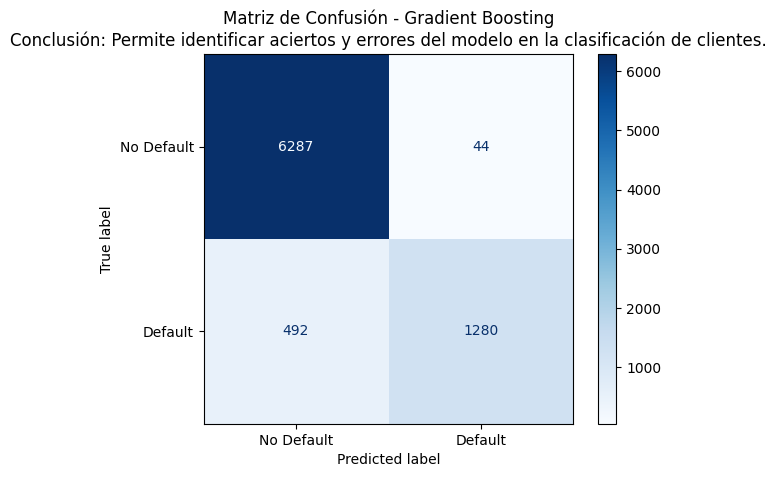

In [15]:
plt.figure(figsize=(6,5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Default','Default']
).plot(
    cmap='Blues'
)

plt.title(
    'Matriz de Confusión - Gradient Boosting\n'
    'Conclusión: Permite identificar aciertos y errores del modelo en la clasificación de clientes.'
)

plt.show()

In [16]:
tn, fp, fn, tp = cm.ravel()

pd.DataFrame(
    {
        'Valor': [
            tn,
            fp,
            fn,
            tp
        ]
    },
    index=[
        'TN',
        'FP',
        'FN',
        'TP'
    ]
)

,Valor
TN,6287
FP,44
FN,492
TP,1280


La matriz de confusión evidencia que el modelo logra identificar correctamente una gran cantidad tanto de clientes cumplidos como de clientes incumplidos. En particular, se observan 6.287 verdaderos negativos y 1.280 verdaderos positivos.

No obstante, el modelo todavía clasifica incorrectamente 492 clientes incumplidos como cumplidos, lo que representa un riesgo importante desde la perspectiva del negocio, ya que estos casos podrían corresponder a créditos aprobados que posteriormente entrarían en default.

Por otra parte, únicamente 44 clientes cumplidos fueron clasificados erróneamente como incumplidos, indicando una baja tasa de falsos positivos.

## Métricas de clasificación



In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

precision = precision_score(
    y_test,
    y_pred_gb
)

recall = recall_score(
    y_test,
    y_pred_gb
)

f1 = f1_score(
    y_test,
    y_pred_gb
)

metricas = pd.DataFrame({
    'Métrica': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC-AUC'
    ],
    'Valor': [
        accuracy,
        precision,
        recall,
        f1,
        auc_gb
    ]
})

metricas.round(4)

print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      6331
           1       0.97      0.72      0.83      1772

    accuracy                           0.93      8103
   macro avg       0.95      0.86      0.89      8103
weighted avg       0.94      0.93      0.93      8103



El modelo Gradient Boosting alcanzó una exactitud global del 93%, evidenciando una alta capacidad de clasificación. La precisión para identificar clientes incumplidos fue del 97%, lo que indica que la mayoría de los clientes clasificados como riesgosos efectivamente presentan incumplimiento.

Por otra parte, el recall alcanzó un valor de 72%, lo que significa que el modelo logra identificar aproximadamente siete de cada diez clientes incumplidos. Aunque aún existen casos que no son detectados, el desempeño general del modelo resulta satisfactorio para una primera aproximación al problema de riesgo crediticio.

Finalmente, el F1-score de 0.83 refleja un adecuado balance entre precisión y recall.

## **Evaluación de distintos thresholds**

Por defecto, los modelos de clasificación utilizan un threshold de 0.5 para convertir probabilidades en clases (0 o 1). Sin embargo, este valor puede modificarse dependiendo de las necesidades del negocio.

En riesgo crediticio resulta especialmente importante analizar cómo cambian las métricas cuando se modifica el threshold, ya que existe un trade-off entre identificar más clientes riesgosos (recall) y evitar falsos positivos (precision).

In [18]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluar_threshold(y_true, y_score, threshold):

    y_pred_thr = (
        y_score >= threshold
    ).astype(int)

    return {
        'threshold': threshold,
        'accuracy': accuracy_score(
            y_true,
            y_pred_thr
        ),
        'precision': precision_score(
            y_true,
            y_pred_thr,
            zero_division=0
        ),
        'recall': recall_score(
            y_true,
            y_pred_thr,
            zero_division=0
        ),
        'f1': f1_score(
            y_true,
            y_pred_thr,
            zero_division=0
        )
    }

threshold_results = pd.DataFrame([

    evaluar_threshold(
        y_test,
        y_pred_proba_gb,
        thr
    )

    for thr in [
        0.20,
        0.30,
        0.40,
        0.50,
        0.60,
        0.70,
        0.80
    ]
])

threshold_results.round(4)

,threshold,accuracy,precision,recall,f1
0,0.2,0.8944,0.7403,0.7963,0.7673
1,0.3,0.9194,0.8589,0.7556,0.8040
2,0.4,0.9301,0.9283,0.7376,0.8220
3,0.5,0.9339,0.9668,0.7223,0.8269
4,0.6,0.9322,0.9811,0.7037,0.8196
5,0.7,0.9276,0.9885,0.6766,0.8034
6,0.8,0.9178,0.9982,0.6253,0.7689


Se evaluaron distintos valores de threshold con el objetivo de analizar el comportamiento de las métricas de clasificación. Aunque thresholds más bajos permiten capturar una mayor proporción de clientes incumplidos, también incrementan los falsos positivos. Por el contrario, valores más altos mejoran la precisión pero reducen la capacidad de detección. Se seleccionó un threshold de 0.50 debido a que presenta el mejor balance entre Precision y Recall, alcanzando el mayor F1 Score (0.8269) y la mayor Accuracy (0.9339) entre los valores evaluados.

# **Comparación de modelos**

Aunque el ROC-AUC es una de las métricas más utilizadas para evaluar la capacidad de discriminación de un modelo, no resulta suficiente para seleccionar la mejor alternativa en un problema de riesgo crediticio.

En este contexto, los costos asociados a los errores de clasificación son diferentes. Particularmente, un falso negativo representa un cliente que realmente incumple sus obligaciones financieras pero que es clasificado como un cliente cumplido. Este tipo de error puede traducirse en pérdidas económicas para la entidad financiera debido a la aprobación de créditos a clientes con alta probabilidad de default.

Por esta razón, además del ROC-AUC, se analizarán métricas como Accuracy, Precision, Recall y F1-Score para cada uno de los modelos evaluados. Esto permitirá seleccionar la alternativa que presente el mejor balance entre capacidad de discriminación y capacidad de identificación de clientes riesgosos.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluar_modelo(
    nombre,
    modelo,
    X_test,
    y_test
):

    y_pred = modelo.predict(X_test)

    y_pred_proba = modelo.predict_proba(X_test)[:,1]

    return {
        'Modelo': nombre,
        'Accuracy': accuracy_score(
            y_test,
            y_pred
        ),
        'Precision': precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        'Recall': recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        'F1': f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        'ROC_AUC': roc_auc_score(
            y_test,
            y_pred_proba
        )
    }

resultados_modelos = pd.DataFrame([

    evaluar_modelo(
        'Logistic StandardScaler',
        model_simple,
        X_test,
        y_test
    ),

    evaluar_modelo(
        'Logistic Polynomial',
        model_poly,
        X_test,
        y_test
    ),

    evaluar_modelo(
        'Random Forest',
        model_rf,
        X_test,
        y_test
    ),

    evaluar_modelo(
        'Gradient Boosting',
        model_gb,
        X_test,
        y_test
    ),

    evaluar_modelo(
        'Decision Tree',
        model_dt,
        X_test,
        y_test
    ),

    evaluar_modelo(
        'AdaBoost',
        model_ada,
        X_test,
        y_test
    )

])

resultados_modelos = resultados_modelos.round(4)

resultados_modelos.sort_values(
    by='ROC_AUC',
    ascending=False
)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
3,Gradient Boosting,0.9339,0.9668,0.7223,0.8269,0.9334
2,Random Forest,0.9340,0.9682,0.7218,0.8270,0.9305
1,Logistic Polynomial,0.9028,0.8591,0.6642,0.7492,0.9143
5,AdaBoost,0.9052,0.8586,0.6783,0.7579,0.9132
0,Logistic StandardScaler,0.8778,0.7833,0.6100,0.6859,0.8815
4,Decision Tree,0.8897,0.7335,0.7782,0.7552,0.8495


# **Selección del modelo final**

La selección del modelo no se realizó únicamente con base en el valor del ROC-AUC, sino considerando también métricas como Precision, Recall y F1-Score, debido a las implicaciones de negocio asociadas al riesgo crediticio.

Aunque el árbol de decisión obtuvo el mayor Recall (77,82%), presentó una reducción importante en Precision (73,35%) y en ROC-AUC (84,95%), lo que indica una mayor cantidad de falsas alarmas y una menor capacidad general de discriminación.

Por otra parte, Gradient Boosting y Random Forest mostraron desempeños muy similares. Sin embargo, Gradient Boosting alcanzó el mayor ROC-AUC (93,34%), manteniendo simultáneamente valores elevados de Precision (96,68%), Recall (72,23%) y F1-Score (82,69%).

Considerando el balance entre capacidad de discriminación, identificación de clientes incumplidos y reducción de errores de clasificación, se seleccionó Gradient Boosting como modelo final del proyecto.

## Comparación visual de los modelos evaluados

Con el fin de facilitar la comparación entre los modelos evaluados, se construyó una visualización de la métrica ROC-AUC. Esta métrica permite medir la capacidad de discriminación de cada modelo para diferenciar entre clientes cumplidos e incumplidos.

/tmp/ipykernel_2136/2343342720.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


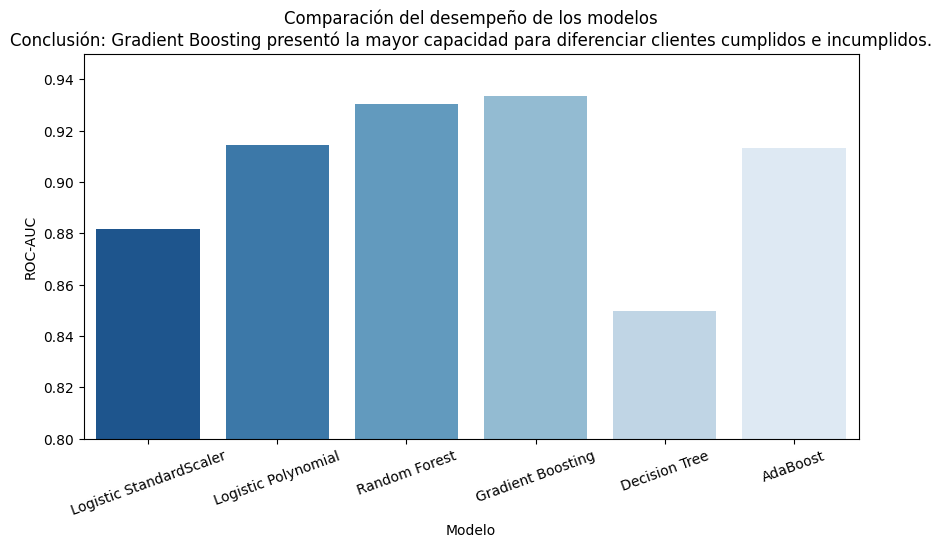

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.barplot(
    data=resultados_modelos,
    x='Modelo',
    y='ROC_AUC',
    palette='Blues_r'
)

plt.title(
    'Comparación del desempeño de los modelos\n'
    'Conclusión: Gradient Boosting presentó la mayor capacidad para diferenciar clientes cumplidos e incumplidos.'
)

plt.xlabel('Modelo')
plt.ylabel('ROC-AUC')

plt.xticks(rotation=20)

plt.ylim(0.80, 0.95)

plt.show()

Los modelos de tipo ensamblado obtuvieron los mejores resultados dentro del ejercicio. En particular, Gradient Boosting alcanzó el mayor ROC-AUC (0.9334), seguido muy de cerca por Random Forest (0.9305).

Aunque Decision Tree obtuvo el mayor Recall (77.82%), presentó un deterioro importante en Precision y ROC-AUC, evidenciando una menor capacidad general de clasificación.

Considerando el balance entre Precision, Recall, F1 Score y ROC-AUC, se seleccionó Gradient Boosting como modelo final del proyecto.

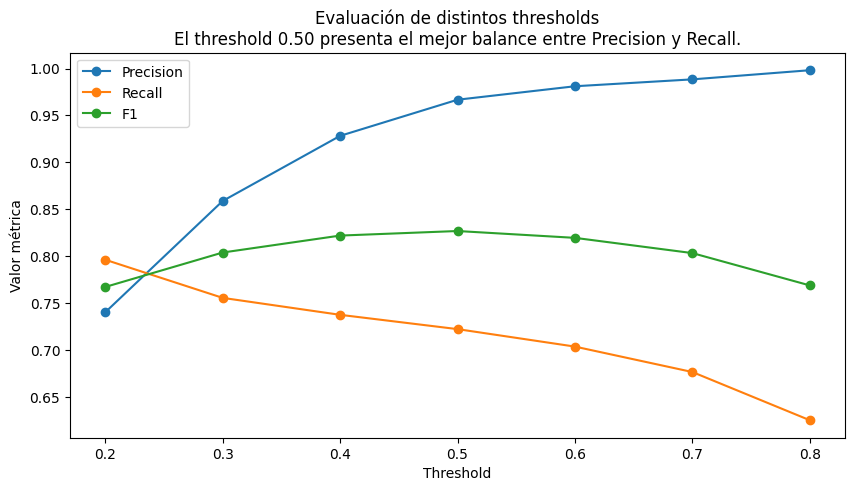

In [22]:
plt.figure(figsize=(10,5))

plt.plot(
    threshold_results['threshold'],
    threshold_results['precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_results['threshold'],
    threshold_results['recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_results['threshold'],
    threshold_results['f1'],
    marker='o',
    label='F1'
)

plt.title(
    'Evaluación de distintos thresholds\n'
    'El threshold 0.50 presenta el mejor balance entre Precision y Recall.'
)

plt.xlabel('Threshold')
plt.ylabel('Valor métrica')

plt.legend()

plt.show()

Se evaluaron distintos valores de threshold con el fin de analizar el comportamiento de las métricas de clasificación. Se observó que valores bajos incrementan el Recall pero reducen la Precision, mientras que valores altos generan el efecto contrario.

El threshold de 0.50 presentó el mejor balance entre Precision (96.68%), Recall (72.23%) y F1 Score (82.69%), alcanzando además la mayor Accuracy observada. Por esta razón se seleccionó como valor final para la clasificación de clientes cumplidos e incumplidos.

# **Conclusiones Generales del Proyecto**

El análisis exploratorio permitió identificar que el incumplimiento crediticio está asociado principalmente a variables relacionadas con la calidad crediticia, la capacidad de pago y el comportamiento financiero histórico de los solicitantes.

Durante el EDA se encontró que variables como la calificación crediticia (`loan_grade`), el porcentaje de ingreso comprometido (`loan_percent_income`), el historial de incumplimiento (`default_historico`) y las variables derivadas asociadas al nivel de endeudamiento presentaban una relación importante con la variable objetivo (`loan_status`).

Posteriormente, se desarrolló un proceso de Feature Engineering que permitió construir variables adicionales relacionadas con edad, nivel de ingresos, endeudamiento y riesgo crediticio. Estas variables enriquecieron el análisis y mejoraron la capacidad predictiva de los modelos evaluados.

Con el fin de identificar la mejor solución para el problema, se compararon diferentes esquemas de preprocesamiento y distintos algoritmos de clasificación. Los resultados mostraron que los modelos de ensamblado superan ampliamente a los modelos lineales y a los árboles individuales.

El modelo Gradient Boosting obtuvo el mejor desempeño general, alcanzando un ROC-AUC de 0.9334, una Accuracy de 0.9339, una Precision de 0.9668 y un F1-Score de 0.8269. Estos resultados evidencian una excelente capacidad para diferenciar entre clientes cumplidos e incumplidos.

Aunque el modelo Decision Tree presentó el mayor Recall, su desempeño global fue inferior al de los modelos de ensamblado. Por esta razón, la selección final se realizó considerando simultáneamente ROC-AUC, Precision, Recall y F1-Score, y no únicamente una métrica aislada.

Finalmente, se evaluaron distintos valores de threshold para analizar el comportamiento del modelo desde la perspectiva del negocio. Se seleccionó un threshold de 0.50 debido a que presentó el mejor equilibrio entre Precision y Recall, minimizando la probabilidad de aprobar clientes con alto riesgo de incumplimiento sin incrementar excesivamente los falsos positivos.

En conclusión, el modelo seleccionado constituye una herramienta sólida para apoyar procesos de evaluación crediticia, permitiendo identificar de manera temprana clientes con mayor probabilidad de incumplimiento y facilitando una gestión más eficiente del riesgo.

Integrantes
1.   Maria Sofia Sepulveda Villa
2.   Jesica Roman Martinez